In [4]:
# Solar Power Generation - Regression

## 1. Introduction
# The objective of this project is to develop machine learning regression models
# for predicting solar power generation using the Solar Power Generation dataset.
# The project includes data exploration, preprocessing, feature engineering,
# model training, model comparison, hyperparameter tuning, and evaluation.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
generation_1 = pd.read_csv("../data/solar/Plant_1_Generation_Data.csv")
print("Plant 1 Generation:", generation_1.shape)


Plant 1 Generation: (68778, 7)


In [7]:
# First 5 rows of each dataset

print("Plant 1 Generation:")
display(generation_1.head())



Plant 1 Generation:


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [8]:
# Dataset Information

print("===== Plant 1 Generation Info =====")
generation_1.info()


===== Plant 1 Generation Info =====
<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  str    
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  str    
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 3.7 MB


In [9]:
# Descriptive Statistics

print("===== Plant 1 Generation Statistics =====")
display(generation_1.describe())


===== Plant 1 Generation Statistics =====


,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04
mean,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06
std,0.0,4036.457169,394.396439,3145.178309,4.162720e+05
min,4135001.0,0.000000,0.000000,0.000000,6.183645e+06
25%,4135001.0,0.000000,0.000000,0.000000,6.512003e+06
50%,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06
75%,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06
max,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06


In [10]:
# Missing Value Analysis

print("Missing values in Plant 1 Generation:")
display(generation_1.isnull().sum())


print("\nTotal missing values:")
print("Generation:", generation_1.isnull().sum().sum())


Missing values in Plant 1 Generation:


DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64


Total missing values:
Generation: 0


 Observation

No missing values were found in the selected datasets. Therefore, no missing-value imputation was required.

In [11]:
# If missing values were present, handle them before moving to modeling.

# generation_1 = generation_1.fillna(generation_1.median(numeric_only=True))
# weather_1 = weather_1.fillna(weather_1.median(numeric_only=True))

In [12]:
# Duplicate Analysis

print("Duplicate rows in Plant 1 Generation:",
      generation_1.duplicated().sum())



Duplicate rows in Plant 1 Generation: 0


 Duplicate Observation

Duplicate records were checked to prevent repeated observations from affecting the regression analysis.

In [13]:
# If duplicate rows are found, remove the duplicate rows before modeling.
# # Remove duplicate rows

# generation_1 = generation_1.drop_duplicates()
# weather_1 = weather_1.drop_duplicates()

# print("Duplicate rows after removal:")
# print("Generation:", generation_1.duplicated().sum())
# print("Weather:", weather_1.duplicated().sum())

Numerical features:
['PLANT_ID', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']


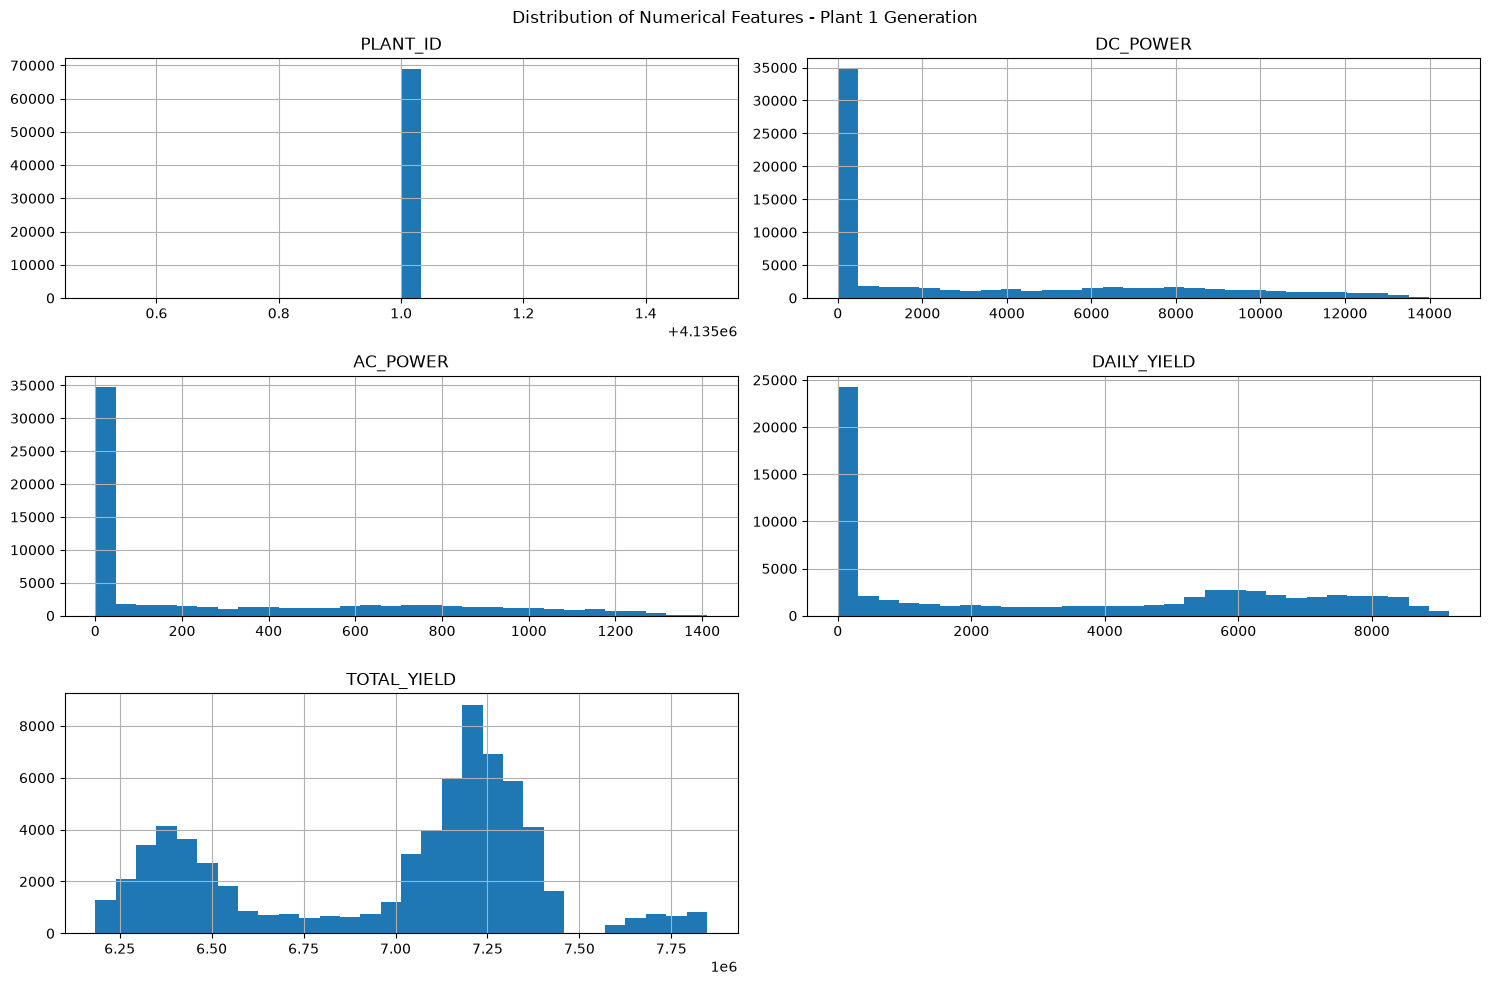

In [14]:
# Feature Distribution Plots

numeric_columns = generation_1.select_dtypes(include=np.number).columns

print("Numerical features:")
print(numeric_columns.tolist())

generation_1[numeric_columns].hist(
    figsize=(15, 10),
    bins=30
)

plt.suptitle("Distribution of Numerical Features - Plant 1 Generation")
plt.tight_layout()
plt.show()

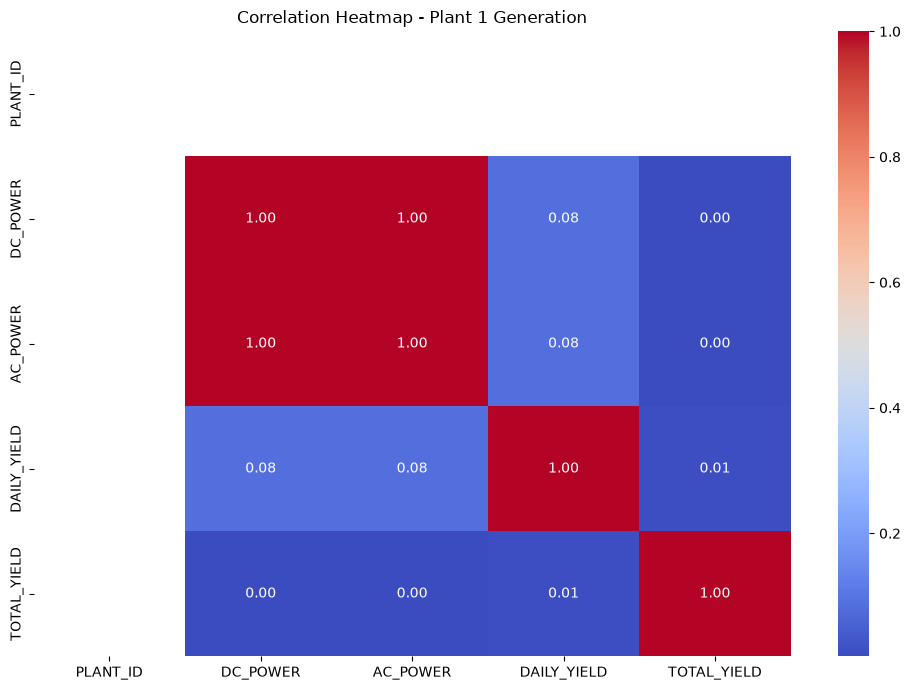

In [15]:
# Correlation Heatmap - Generation Data

plt.figure(figsize=(10, 7))

correlation_matrix = generation_1[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap - Plant 1 Generation")
plt.tight_layout()
plt.show()

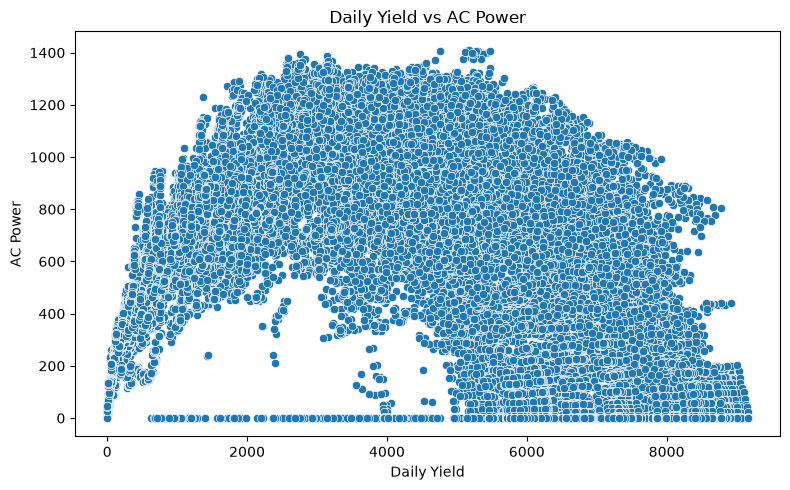

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=generation_1,
    x="DAILY_YIELD",
    y="AC_POWER"
)

plt.title("Daily Yield vs AC Power")
plt.xlabel("Daily Yield")
plt.ylabel("AC Power")
plt.tight_layout()
plt.show()

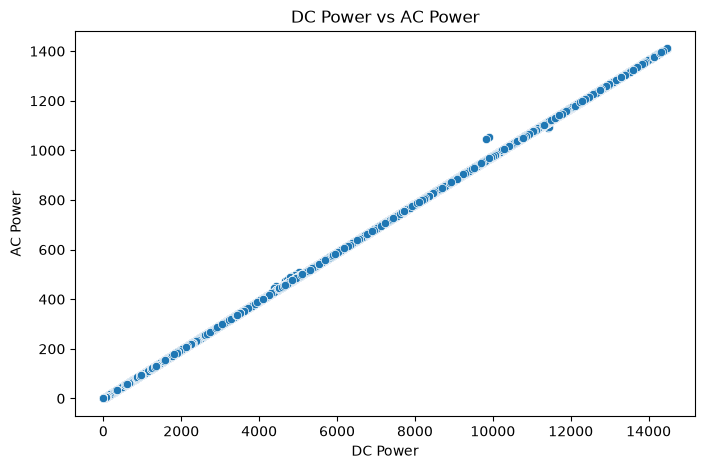

In [17]:
# Feature-Target Relationship: DC Power vs AC Power

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=generation_1,
    x="DC_POWER",
    y="AC_POWER"
)

plt.title("DC Power vs AC Power")
plt.xlabel("DC Power")
plt.ylabel("AC Power")
plt.show()

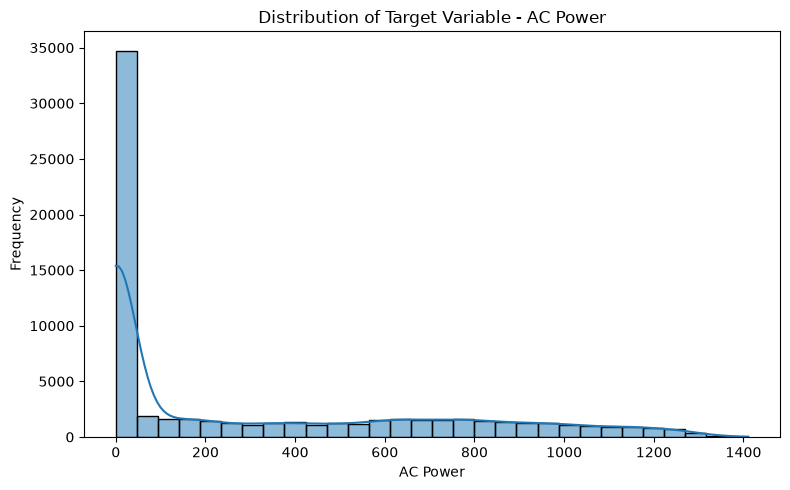

In [18]:
# Target Distribution - AC Power

plt.figure(figsize=(8, 5))

sns.histplot(
    data=generation_1,
    x="AC_POWER",
    bins=30,
    kde=True
)

plt.title("Distribution of Target Variable - AC Power")
plt.xlabel("AC Power")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

 EDA Observations

# - The distribution plots show the spread and variation of the numerical features in the dataset.
# - The correlation heatmap helps identify the strength and direction of relationships between the numerical variables.
# - The DC Power vs AC Power scatter plot shows a very strong positive relationship between DC Power and AC Power.
# - As DC Power increases, AC Power also increases almost proportionally, indicating that DC Power is an important feature for predicting AC Power.
# - The EDA provides useful insights into the relationships between the features and helps guide the preprocessing and model-building stages.

In [19]:
## 3. Data Cleaning and Preprocessing

df = generation_1.copy()

print("Original shape:", df.shape)
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

Original shape: (68778, 7)
DATE_TIME      0
PLANT_ID       0
SOURCE_KEY     0
DC_POWER       0
AC_POWER       0
DAILY_YIELD    0
TOTAL_YIELD    0
dtype: int64
Duplicate rows: 0


In [20]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (68778, 7)


In [21]:
df["DATE_TIME"] = pd.to_datetime(df["DATE_TIME"], dayfirst=True)
print(df["DATE_TIME"].dtype)
df["hour"] = df["DATE_TIME"].dt.hour
df["day"] = df["DATE_TIME"].dt.day
df["month"] = df["DATE_TIME"].dt.month
df["day_of_week"] = df["DATE_TIME"].dt.dayofweek

datetime64[us]


Feature Engineering: The date and time information was converted into useful features such as hour, day, month, and day of the week.

Feature Engineering Justification

The DATE_TIME column was converted into hour, day, month, and
day_of_week features to capture temporal patterns in solar power
generation. These time-based features may help the regression models
learn variations in power generation over time.

In [22]:
df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,hour,day,month,day_of_week
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,0,15,5,4
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,0,15,5,4
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,0,15,5,4
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,0,15,5,4
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,0,15,5,4


In [23]:
df.describe()

,DATE_TIME,PLANT_ID,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,hour,day,month,day_of_week
count,68778,68778.0,68778.000000,68778.000000,68778.000000,6.877800e+04,68778.000000,68778.000000,68778.000000,68778.000000
mean,2020-06-01 08:02:49.458257,4135001.0,3147.426211,307.802752,3295.968737,6.978712e+06,11.567216,15.762133,5.518567,2.991160
min,2020-05-15 00:00:00,4135001.0,0.000000,0.000000,0.000000,6.183645e+06,0.000000,1.000000,5.000000,0.000000
25%,2020-05-24 00:45:00,4135001.0,0.000000,0.000000,0.000000,6.512003e+06,6.000000,9.000000,5.000000,1.000000
50%,2020-06-01 14:30:00,4135001.0,429.000000,41.493750,2658.714286,7.146685e+06,12.000000,16.000000,6.000000,3.000000
75%,2020-06-09 20:00:00,4135001.0,6366.964286,623.618750,6274.000000,7.268706e+06,17.000000,23.000000,6.000000,5.000000
max,2020-06-17 23:45:00,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06,23.000000,31.000000,6.000000,6.000000
std,NaN,0.0,4036.457169,394.396439,3145.178309,4.162720e+05,6.862477,8.554765,0.499659,2.058307


In [24]:
# Outlier Detection using IQR

features = ["DC_POWER", "AC_POWER", "DAILY_YIELD", "TOTAL_YIELD"]

for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(col, ":", len(outliers), "outliers")

DC_POWER : 0 outliers
AC_POWER : 0 outliers
DAILY_YIELD : 0 outliers
TOTAL_YIELD : 0 outliers


In [25]:
# If outliers are found

# # Handle Outliers using IQR

# features = ["DC_POWER", "AC_POWER", "DAILY_YIELD", "TOTAL_YIELD"]

# for col in features:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1

#     lower = Q1 - 1.5 * IQR
#     upper = Q3 + 1.5 * IQR

#     # Remove outliers
#     df = df[(df[col] >= lower) & (df[col] <= upper)]

# print("Shape after outlier removal:", df.shape)


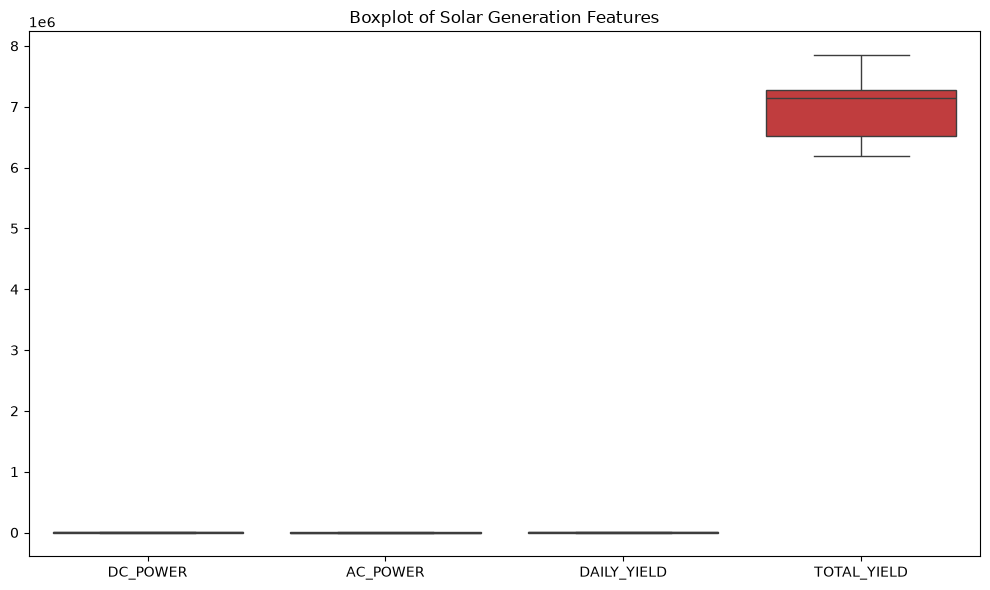

In [26]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[["DC_POWER", "AC_POWER", "DAILY_YIELD", "TOTAL_YIELD"]])

plt.title("Boxplot of Solar Generation Features")
plt.tight_layout()
plt.show()

Outlier Detection: Boxplots were used to identify possible outliers in the solar power generation features.

 Outlier Treatment

Outliers were checked using the Interquartile Range (IQR) method.
The IQR analysis identified zero outliers in the selected solar
generation features. Therefore, no outlier removal or transformation
was required, and the original observations were retained.

In [27]:
y = df["AC_POWER"]

In [28]:
# Target variable
y = df["AC_POWER"]

# Input features
X = df[
    [
        "DC_POWER",
        "DAILY_YIELD",
        "TOTAL_YIELD",
        "hour",
        "day",
        "month",
        "day_of_week"
    ]
]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (68778, 7)
y shape: (68778,)


# Categorical Feature Handling

The columns PLANT_ID and SOURCE_KEY are categorical identifiers. They were not included in the final regression feature set because the model focuses on numerical power-generation and time-based features. Therefore, categorical encoding was not required for the selected features.

In [29]:
#stratified train/test split
from sklearn.model_selection import train_test_split

y_bins = pd.qcut(y, q=10, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_bins
)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed!")

Scaling completed!


In [31]:
print("Final Preprocessed Data")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nMissing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

print("Missing values in y_train:", y_train.isnull().sum())
print("Missing values in y_test:", y_test.isnull().sum())

print("\nScaled X_train shape:", X_train_scaled.shape)
print("Scaled X_test shape:", X_test_scaled.shape)

Final Preprocessed Data
X_train shape: (55022, 7)
X_test shape: (13756, 7)
y_train shape: (55022,)
y_test shape: (13756,)

Missing values in X_train: 0
Missing values in X_test: 0
Missing values in y_train: 0
Missing values in y_test: 0

Scaled X_train shape: (55022, 7)
Scaled X_test shape: (13756, 7)


In [32]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

In [33]:
# 1. Linear Regression
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

print("Linear Regression")
print("R2 Score:", r2_score(y_test, y_pred_linear))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_linear)))
print("MAE:", mean_absolute_error(y_test, y_pred_linear))

Linear Regression
R2 Score: 0.9999900814173539
RMSE: 1.243599107917871
MAE: 0.7069851918321723


In [34]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

print(coefficients)
print("Intercept:", linear_model.intercept_)

       Feature  Coefficient
0     DC_POWER   394.278287
1  DAILY_YIELD    -0.068166
2  TOTAL_YIELD    -0.010973
3         hour     0.053721
4          day    -0.004319
5        month     0.032278
6  day_of_week     0.000940
Intercept: 307.8160492222835


Coefficient Interpretation

The coefficients show the effect of each feature on the predicted AC_POWER.

Positive coefficient: feature increases AC_POWER.
Negative coefficient: feature decreases AC_POWER.
Larger absolute value: stronger effect on the prediction.

Since the features are standardized, the coefficients represent the effect of a one-standard-deviation increase in each feature.

In [35]:
# 2. Polynomial Regression
for degree in [2, 3]:
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)

    y_pred_poly = poly_model.predict(X_test_poly)

    print("Polynomial Degree:", degree)
    print("R2 Score:", r2_score(y_test, y_pred_poly))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))
    print("MAE:", mean_absolute_error(y_test, y_pred_poly))
    print()

Polynomial Degree: 2
R2 Score: 0.9999948991592494
RMSE: 0.8918184978363484
MAE: 0.2642157189488667

Polynomial Degree: 3
R2 Score: 0.9999949628363274
RMSE: 0.886234443628043
MAE: 0.24719467158401362



In [36]:
# 3. Ridge Regression
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

print("Ridge Regression")
print("R2 Score:", r2_score(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("MAE:", mean_absolute_error(y_test, y_pred_ridge))

Ridge Regression
R2 Score: 0.999990081437874
RMSE: 1.2435978215063697
MAE: 0.7100077209139498


In [37]:
# 4. Lasso Regression
lasso_model = Lasso(alpha=0.01)

lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

print("Lasso Regression")
print("R2 Score:", r2_score(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("MAE:", mean_absolute_error(y_test, y_pred_lasso))

Lasso Regression
R2 Score: 0.9999900793840241
RMSE: 1.2437265715761663
MAE: 0.7112527697528398


In [38]:
# Observe feature sparsity
lasso_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_model.coef_
})

print(lasso_coefficients)

print("Number of zero coefficients:",
      np.sum(lasso_model.coef_ == 0))
for feature, coefficient in zip(X.columns, lasso_model.coef_):
    print(feature, ":", coefficient)

       Feature  Coefficient
0     DC_POWER   394.264527
1  DAILY_YIELD    -0.012185
2  TOTAL_YIELD    -0.000000
3         hour     0.000000
4          day    -0.013392
5        month     0.012505
6  day_of_week    -0.000000
Number of zero coefficients: 3
DC_POWER : 394.2645271482212
DAILY_YIELD : -0.0121852877296586
TOTAL_YIELD : -0.0
hour : 0.0
day : -0.013392497950455568
month : 0.01250463150565866
day_of_week : -0.0


In [39]:
# 5. Elastic Net Regression
elastic_model = ElasticNet(alpha=0.01, l1_ratio=0.5)

elastic_model.fit(X_train_scaled, y_train)

y_pred_elastic = elastic_model.predict(X_test_scaled)

print("Elastic Net Regression")
print("R2 Score:", r2_score(y_test, y_pred_elastic))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_elastic)))
print("MAE:", mean_absolute_error(y_test, y_pred_elastic))

Elastic Net Regression
R2 Score: 0.9999650563098674
RMSE: 2.3342102747150277
MAE: 2.0605091807932454


In [40]:
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

for ratio in l1_ratios:
    elastic_tuned = ElasticNet(alpha=0.01, l1_ratio=ratio)

    elastic_tuned.fit(X_train_scaled, y_train)

    y_pred = elastic_tuned.predict(X_test_scaled)

    print("L1 Ratio:", ratio)
    print("R2 Score:", r2_score(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print()

L1 Ratio: 0.1
R2 Score: 0.9999097644907612
RMSE: 3.750976388902222
MAE: 3.4018429685806137

L1 Ratio: 0.3
R2 Score: 0.9999412714909308
RMSE: 3.0260777440128432
MAE: 2.7315948616776606

L1 Ratio: 0.5
R2 Score: 0.9999650563098674
RMSE: 2.3342102747150277
MAE: 2.0605091807932454

L1 Ratio: 0.7
R2 Score: 0.9999810161244664
RMSE: 1.7204736776495102
MAE: 1.3933777194693917

L1 Ratio: 0.9
R2 Score: 0.9999890434911429
RMSE: 1.3070484629013808
MAE: 0.894585451217591



In [41]:
# ## 6. Decision Tree Regression

# Decision Tree Regression predicts the target by recursively splitting the data into smaller groups.

# The max_depth parameter controls the depth of the tree and helps control model complexity.

In [42]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_r2 = r2_score(y_test, dt_predictions)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_predictions))
dt_mae = mean_absolute_error(y_test, dt_predictions)

print("Decision Tree Regression")
print("R2   :", dt_r2)
print("RMSE :", dt_rmse)
print("MAE  :", dt_mae)

Decision Tree Regression
R2   : 0.9999945147770496
RMSE : 0.9248104657324978
MAE  : 0.2489696931787884


In [43]:
# Hyperparameter Tuning - Decision Tree

from sklearn.model_selection import GridSearchCV

dt_params = {
    "max_depth": [5, 10, 15, 20, None]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    cv=5,
    scoring="r2"
)

dt_grid.fit(X_train, y_train)

print("Decision Tree Tuning")
print("Best Parameters:", dt_grid.best_params_)
print("Best CV R2:", dt_grid.best_score_)

Decision Tree Tuning
Best Parameters: {'max_depth': 20}
Best CV R2: 0.9999958610044617


In [44]:
# ## 7. Random Forest Regression

# Random Forest Regression is an ensemble method that combines multiple decision trees.

# The n_estimators parameter specifies the number of trees used in the ensemble.

In [45]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_mae = mean_absolute_error(y_test, rf_predictions)

print("Random Forest Regression")
print("R2   :", rf_r2)
print("RMSE :", rf_rmse)
print("MAE  :", rf_mae)

Random Forest Regression
R2   : 0.9999952190475992
RMSE : 0.8634015094248219
MAE  : 0.13810354461322066


In [46]:
# Hyperparameter Tuning - Random Forest

rf_params = {
    "n_estimators": [50, 100, 150, 200, 250]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params,
    cv=5,
    scoring="r2"
)

rf_grid.fit(X_train, y_train)

print("Random Forest Tuning")
print("Best Parameters:", rf_grid.best_params_)
print("Best CV R2:", rf_grid.best_score_)

KeyboardInterrupt: 

 Feature Importance Observation

The Random Forest feature importance plot shows the relative contribution of each input feature to predicting AC Power. DC_POWER has the highest importance, indicating that it contributes strongly to the prediction of AC_POWER.

In [ ]:
# ## 8. Gradient Boosting Regression

# Gradient Boosting builds prediction models sequentially, where each new model attempts to reduce the errors of the previous models.

# The learning_rate controls the contribution of each tree to the final prediction.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

gb_r2 = r2_score(y_test, gb_predictions)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
gb_mae = mean_absolute_error(y_test, gb_predictions)

print("Gradient Boosting Regression")
print("R2   :", gb_r2)
print("RMSE :", gb_rmse)
print("MAE  :", gb_mae)

Gradient Boosting Regression
R2   : 0.9999680397053503
RMSE : 2.2323432881389103
MAE  : 1.1690146156991983


In [ ]:
# Hyperparameter Tuning - Gradient Boosting

gb_params = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(
        n_estimators=100,
        max_depth=3,
        random_state=42
    ),
    gb_params,
    cv=5,
    scoring="r2"
)

gb_grid.fit(X_train, y_train)

print("Gradient Boosting Tuning")
print("Best Parameters:", gb_grid.best_params_)
print("Best CV R2:", gb_grid.best_score_)

Gradient Boosting Tuning
Best Parameters: {'learning_rate': 0.1}
Best CV R2: 0.9999709281853937


In [ ]:
# ## 9. Support Vector Regression

# Support Vector Regression predicts continuous target values by finding a function that fits the data within an acceptable error margin.

# Feature scaling is important because SVR is sensitive to feature magnitudes.
# The C parameter controls the penalty for prediction errors, while the kernel determines the type of transformation used.

In [ ]:
#code for svr
# Support Vector Regression (SVR)

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV

# Use a smaller sample because SVR is slow on large datasets
sample_size = 10000

X_train_svr = X_train_scaled[:sample_size]
y_train_svr = y_train[:sample_size]

# Tune C and kernel
svr_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

svr_grid = GridSearchCV(
    SVR(),
    svr_params,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

svr_grid.fit(X_train_svr, y_train_svr)

print("Best C:", svr_grid.best_params_['C'])
print("Best Kernel:", svr_grid.best_params_['kernel'])
print("Best CV R2:", svr_grid.best_score_)

# Final SVR model
svr_model = SVR(
    C=svr_grid.best_params_['C'],
    kernel=svr_grid.best_params_['kernel']
)

svr_model.fit(X_train_svr, y_train_svr)

# Prediction
svr_predictions = svr_model.predict(X_test_scaled)

# Evaluation
svr_r2 = r2_score(y_test, svr_predictions)
svr_rmse = np.sqrt(mean_squared_error(y_test, svr_predictions))
svr_mae = mean_absolute_error(y_test, svr_predictions)

print("\nSupport Vector Regression")
print("R2   :", svr_r2)
print("RMSE :", svr_rmse)
print("MAE  :", svr_mae)

Best C: 1
Best Kernel: linear
Best CV R2: 0.9999929594054896

Support Vector Regression
R2   : 0.9999896298740799
RMSE : 1.271591477671773
MAE  : 0.6173766779437948


In [ ]:
## 10. K-Nearest Neighbors Regression

# KNN Regression predicts a target value using the target values of nearby training samples.

# Feature scaling is important because KNN uses distance calculations. The number of neighbors is controlled by the k value.# 

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

knn_predictions = knn_model.predict(X_test_scaled)

knn_r2 = r2_score(y_test, knn_predictions)
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_predictions))
knn_mae = mean_absolute_error(y_test, knn_predictions)

print("K-Nearest Neighbors Regression")
print("R2   :", knn_r2)
print("RMSE :", knn_rmse)
print("MAE  :", knn_mae)

K-Nearest Neighbors Regression
R2   : 0.9977983089599393
RMSE : 18.52822351328226
MAE  : 9.73309229630333


In [ ]:
# Regression Model Comparison
results = {
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Elastic Net",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR",
        "KNN"
    ],
    "R2": [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_poly),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_elastic),
        dt_r2,
        rf_r2,
        gb_r2,
        svr_r2,
        knn_r2
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_linear)),
        np.sqrt(mean_squared_error(y_test, y_pred_poly)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_elastic)),
        dt_rmse,
        rf_rmse,
        gb_rmse,
        svr_rmse,
        knn_rmse
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_pred_poly),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_elastic),
        dt_mae,
        rf_mae,
        gb_mae,
        svr_mae,
        knn_mae
    ]
}

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

results_df

,Model,R2,RMSE,MAE
0,Random Forest,0.999995,0.863402,0.138104
1,Polynomial Regression,0.999995,0.886234,0.247195
2,Decision Tree,0.999995,0.924810,0.248970
3,Ridge Regression,0.999990,1.243598,0.710008
4,Linear Regression,0.999990,1.243599,0.706985
5,Lasso Regression,0.999990,1.243727,0.711253
6,SVR,0.999990,1.271591,0.617377
7,Gradient Boosting,0.999968,2.232343,1.169015
8,Elastic Net,0.999965,2.334210,2.060509
9,KNN,0.997798,18.528224,9.733092


In [ ]:
# Hyperparameter tuning
#model 1:Ridge
from sklearn.model_selection import GridSearchCV

ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train_scaled, y_train)

print("Best Ridge Parameters:", ridge_grid.best_params_)
print("Best Ridge CV R2:", ridge_grid.best_score_)

Best Ridge Parameters: {'alpha': 0.01}
Best Ridge CV R2: 0.999993120624523


In [ ]:
# Ridge Regression - Improvement After Tuning
ridge_before_r2 = r2_score(y_test, y_pred_ridge)

ridge_tuned_pred = ridge_grid.predict(X_test_scaled)

ridge_after_r2 = r2_score(y_test, ridge_tuned_pred)

ridge_improvement = ridge_after_r2 - ridge_before_r2

print("Ridge R2 Before Tuning:", ridge_before_r2)
print("Ridge R2 After Tuning:", ridge_after_r2)
print("Ridge R2 Improvement:", ridge_improvement)
print("Best Ridge Parameters:", ridge_grid.best_params_)

Ridge R2 Before Tuning: 0.999990081437874
Ridge R2 After Tuning: 0.9999900814208709
Ridge R2 Improvement: -1.7003176644436735e-11
Best Ridge Parameters: {'alpha': 0.01}


In [ ]:
#model 2 knn
knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11]
}

knn_grid = GridSearchCV(
    KNeighborsRegressor(),
    knn_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

knn_grid.fit(X_train_scaled, y_train)

print("Best KNN Parameters:", knn_grid.best_params_)
print("Best KNN CV R2:", knn_grid.best_score_)

Best KNN Parameters: {'n_neighbors': 5}
Best KNN CV R2: 0.9974872401004437


In [ ]:
# Hyperparameter Tuning Improvement

# ----- Ridge Regression -----
ridge_before = Ridge(alpha=1)
ridge_before.fit(X_train_scaled, y_train)

ridge_before_pred = ridge_before.predict(X_test_scaled)
ridge_before_r2 = r2_score(y_test, ridge_before_pred)

ridge_best = ridge_grid.best_estimator_
ridge_after_pred = ridge_best.predict(X_test_scaled)
ridge_after_r2 = r2_score(y_test, ridge_after_pred)

ridge_improvement = ridge_after_r2 - ridge_before_r2


# ----- KNN Regression -----
knn_before = KNeighborsRegressor(n_neighbors=5)
knn_before.fit(X_train_scaled, y_train)

knn_before_pred = knn_before.predict(X_test_scaled)
knn_before_r2 = r2_score(y_test, knn_before_pred)

knn_best = knn_grid.best_estimator_
knn_after_pred = knn_best.predict(X_test_scaled)
knn_after_r2 = r2_score(y_test, knn_after_pred)

knn_improvement = knn_after_r2 - knn_before_r2


# Display Results
print("----- Hyperparameter Tuning Improvement -----")

print("\nRidge Regression")
print("Best Parameters :", ridge_grid.best_params_)
print("Before Tuning R2:", ridge_before_r2)
print("After Tuning R2 :", ridge_after_r2)
print("Improvement     :", ridge_improvement)

print("\nKNN Regression")
print("Best Parameters :", knn_grid.best_params_)
print("Before Tuning R2:", knn_before_r2)
print("After Tuning R2 :", knn_after_r2)
print("Improvement     :", knn_improvement)

----- Hyperparameter Tuning Improvement -----

Ridge Regression
Best Parameters : {'alpha': 0.01}
Before Tuning R2: 0.999990081437874
After Tuning R2 : 0.9999900814208709
Improvement     : -1.7003176644436735e-11

KNN Regression
Best Parameters : {'n_neighbors': 5}
Before Tuning R2: 0.9977983089599393
After Tuning R2 : 0.9977983089599393
Improvement     : 0.0


In [ ]:
# Random Forest 5-Fold Cross-Validation
from sklearn.model_selection import cross_val_score

rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Random Forest 5-Fold R2 Scores:", rf_cv_scores)
print("Random Forest Mean CV R2:", rf_cv_scores.mean())

Random Forest 5-Fold R2 Scores: [0.99999855 0.99999916 0.99999462 0.99999553 0.99999913]
Random Forest Mean CV R2: 0.9999973991508233


In [ ]:
#Polynomial Regression — 5-fold CV
from sklearn.pipeline import Pipeline

poly_cv_model = Pipeline([
    ("poly", PolynomialFeatures(degree=3)),
    ("linear", LinearRegression())
])

poly_cv_scores = cross_val_score(
    poly_cv_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("Polynomial Regression 5-Fold R2 Scores:", poly_cv_scores)
print("Polynomial Regression Mean CV R2:", poly_cv_scores.mean())

Polynomial Regression 5-Fold R2 Scores: [0.99999836 0.99999914 0.99999442 0.999999   0.99999902]
Polynomial Regression Mean CV R2: 0.9999979853713166


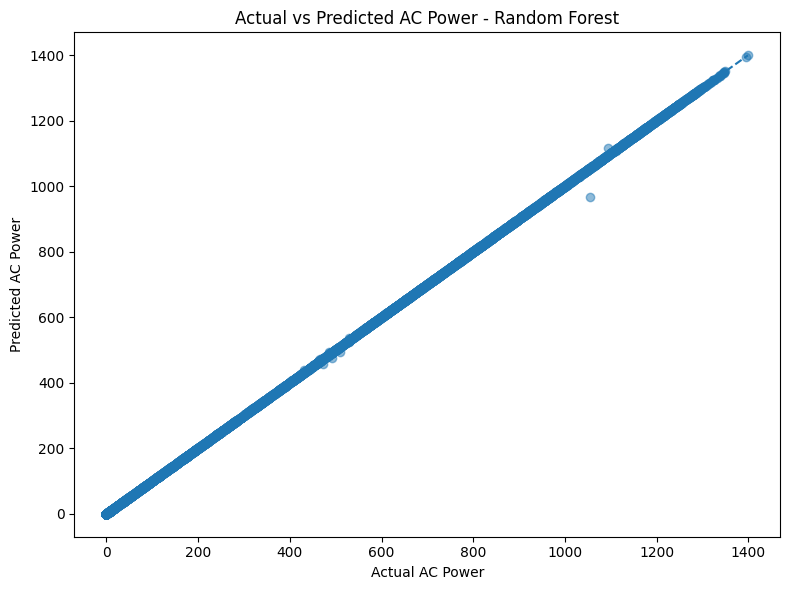

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, rf_predictions, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual AC Power")
plt.ylabel("Predicted AC Power")
plt.title("Actual vs Predicted AC Power - Random Forest")

plt.tight_layout()
plt.show()

 Actual vs Predicted Observation

The predicted values are closely aligned with the actual AC Power values, showing that the Random Forest model provides predictions that are close to the observed values.

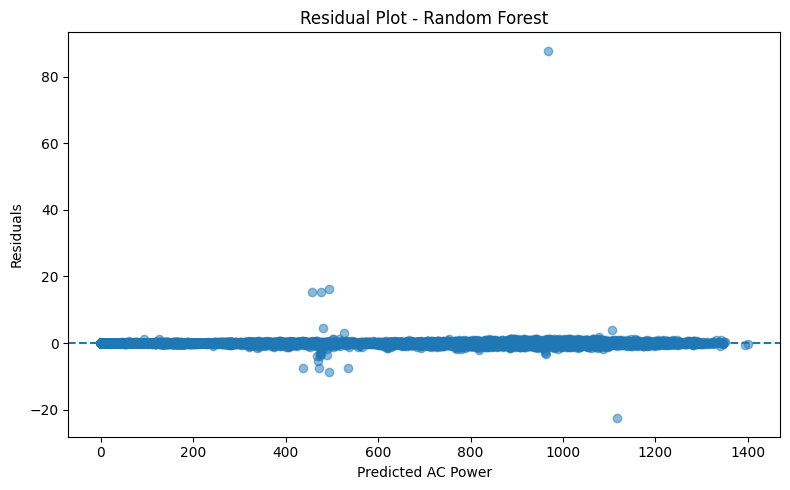

In [ ]:
residuals = y_test - rf_predictions

plt.figure(figsize=(8, 5))

plt.scatter(rf_predictions, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted AC Power")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")

plt.tight_layout()
plt.show()

 Residual Plot Observation

Most residuals are concentrated around zero, indicating that the model predictions are generally close to the actual values. A few larger residuals can be observed for some predictions.

 Regression Conclusion

All ten regression algorithms were trained and evaluated using the same
preprocessed dataset and test set. The models were compared using R²,
RMSE, and MAE. Hyperparameter tuning was performed for two models, and
5-fold cross-validation was applied to the two best-performing models.
Predicted-versus-actual and residual plots were used to further evaluate
the best-performing model.